In [1]:
import math 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
%matplotlib inline
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.eda.utils import *
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')


mpl.style.use('ggplot') 


mpl.rcParams['axes.facecolor']      = 'white'
mpl.rcParams['axes.linewidth']      = 1
mpl.rcParams['xtick.color']         = 'black'
mpl.rcParams['ytick.color']         = 'black'
mpl.rcParams['grid.color']          = 'lightgray'
mpl.rcParams['figure.dpi']          = 150       
mpl.rcParams['axes.grid']           = True
mpl.rcParams['font.size']           = 12



color_palette = ['#003366', '#006699', '#009966', '#F2A900', '#C8102E', '#4B4B4B']


sns.set_palette(sns.color_palette(color_palette))


sns.color_palette(color_palette)


[(0.0, 0.2, 0.4),
 (0.0, 0.4, 0.6),
 (0.0, 0.6, 0.4),
 (0.9490196078431372, 0.6627450980392157, 0.0),
 (0.7843137254901961, 0.06274509803921569, 0.1803921568627451),
 (0.29411764705882354, 0.29411764705882354, 0.29411764705882354)]

In [2]:
data_path = "../data/raw/BankChurners.csv"
df = pd.read_csv(data_path)

In [3]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [5]:
print(f'The dataset has {df.shape[0]} rows and {df.shape[1]} columns.')

The dataset has 10127 rows and 23 columns.


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,3.690378e+07,7.080821e+08,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.632596e+01,8.016814e+00,2.600000e+01,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.346203e+00,1.298908e+00,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.592841e+01,7.986416e+00,1.300000e+01,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.812580e+00,1.554408e+00,1.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.341167e+00,1.010622e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.455317e+00,1.106225e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631954e+03,9.088777e+03,1.438300e+03,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162814e+03,8.149873e+02,0.000000e+00,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9.090685e+03,3.000000e+00,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


Some insights:

Older Demographics: Average age is 46, with most customers between 41-52.

Product Holding: Customers have an average of 4 bank products.

High Inactivity: 75% were inactive for at least 2 months last year.

High Contact Rate: 75% contacted support 2+ times, hinting at dissatisfaction.

Skewed Limits: Average limit is $8,632, but pulled up by a few high-limit accounts.

Low Utilization: Average credit usage is only 28% (half use less than 17.6%).

Low Transaction Rate: Only ~5.4 transactions per month (65/year) on average.

Clean Data: No inconsistencies found in min/max values.

In [7]:
df.isna().sum()

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

In [8]:
df.duplicated().sum()

np.int64(0)

There are no missing or duplicated values.

In [9]:
#it has unique value for each record,not being useful for analysis
df.drop(columns=['CLIENTNUM'],inplace=True)

In [10]:
#standart format because of data manipulation
df.columns= [x.lower() for x in df.columns]

In [11]:
df['gender']=df['gender'].map({'M':1 , 'F':0})
df['attrition_flag']=df['attrition_flag'].map({'Attrited Customer':1, 'Existing Customer':0})

In [12]:
df.rename(columns={'attrition_flag': 'churn_flag'}, inplace=True)

In [13]:
#split the data into train and test sets

In [14]:
X = df.drop(columns=['churn_flag'])
y = df['churn_flag'].copy()

#stratify=y: Ensures the same proportion of Churn classes in both train and test sets due to our imbalanced data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [15]:
#Exploratory data analysis

In [16]:
'''I will get an entire train set (with predictor and target features) in order to use seaborn
'hue' parameter for visualizations and look at the correlation matrix.
'''
train = pd.concat([X_train, y_train], axis=1)
train.head()

,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,...,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,naive_bayes_classifier_attrition_flag_card_category_contacts_count_12_mon_dependent_count_education_level_months_inactive_12_mon_1,naive_bayes_classifier_attrition_flag_card_category_contacts_count_12_mon_dependent_count_education_level_months_inactive_12_mon_2,churn_flag
2856,36,0,0,Unknown,Married,Less than $40K,Blue,24,4,3,...,2230,340.0,0.686,1755,42,0.448,0.868,0.000170,0.99983,0
6515,44,1,3,High School,Single,$60K - $80K,Silver,36,5,2,...,0,25276.0,0.849,2282,38,0.583,0.000,0.994300,0.00570,1
7141,46,1,2,High School,Married,$80K - $120K,Blue,30,6,3,...,915,10755.0,0.892,4277,89,0.854,0.078,0.000105,0.99989,0
632,36,0,2,Graduate,Married,Less than $40K,Blue,24,3,1,...,1593,1531.0,0.869,1652,41,0.367,0.510,0.000093,0.99991,0
3496,50,1,1,Graduate,Single,$120K +,Blue,40,4,2,...,1185,33331.0,0.725,3874,72,0.714,0.034,0.000180,0.99982,0


In [17]:
#seperate lists for categorical, numerical, target features
numerical_features = X_train.select_dtypes('number').columns.tolist()
categorical_features = X_train.select_dtypes('object').columns.tolist()
target = 'churn_flag'

print(f'There are {len(numerical_features)} numerical features. They are: ')
print(numerical_features)
print(f'\nThere are {len(categorical_features)} categorical features. They are: ')
print(categorical_features)
print(f'\nThe target feature is: {target}.')

There are 17 numerical features. They are: 
['customer_age', 'gender', 'dependent_count', 'months_on_book', 'total_relationship_count', 'months_inactive_12_mon', 'contacts_count_12_mon', 'credit_limit', 'total_revolving_bal', 'avg_open_to_buy', 'total_amt_chng_q4_q1', 'total_trans_amt', 'total_trans_ct', 'total_ct_chng_q4_q1', 'avg_utilization_ratio', 'naive_bayes_classifier_attrition_flag_card_category_contacts_count_12_mon_dependent_count_education_level_months_inactive_12_mon_1', 'naive_bayes_classifier_attrition_flag_card_category_contacts_count_12_mon_dependent_count_education_level_months_inactive_12_mon_2']

There are 4 categorical features. They are: 
['education_level', 'marital_status', 'income_category', 'card_category']

The target feature is: churn_flag.


In [18]:
for feature in categorical_features:
    print(feature)
    print('-'*40)
    print(f'There are {train[feature].nunique()} unique values. They are: ')
    print(train[feature].value_counts(normalize=True))
    print()

education_level
----------------------------------------
There are 7 unique values. They are: 
education_level
Graduate         0.306382
High School      0.203679
Unknown          0.148994
Uneducated       0.146031
College          0.098259
Post-Graduate    0.052710
Doctorate        0.043945
Name: proportion, dtype: float64

marital_status
----------------------------------------
There are 4 unique values. They are: 
marital_status
Married     0.463523
Single      0.387853
Unknown     0.074682
Divorced    0.073941
Name: proportion, dtype: float64

income_category
----------------------------------------
There are 6 unique values. They are: 
income_category
Less than $40K    0.349586
$40K - $60K       0.178990
$80K - $120K      0.149241
$60K - $80K       0.140230
Unknown           0.109369
$120K +           0.072584
Name: proportion, dtype: float64

card_category
----------------------------------------
There are 4 unique values. They are: 
card_category
Blue        0.933095
Silver     

In [19]:
# Group the data by churn flag.
churn_grp = train.groupby(['churn_flag'])[['churn_flag']].count().rename(columns={'churn_flag': 'count'}).reset_index()
churn_grp['pct'] = (churn_grp['count'] / churn_grp['count'].sum()) * 100
churn_grp = churn_grp.sort_values(by=['pct'])

In [20]:
churn_grp

,churn_flag,count,pct
1,1,1302,16.07209
0,0,6799,83.92791


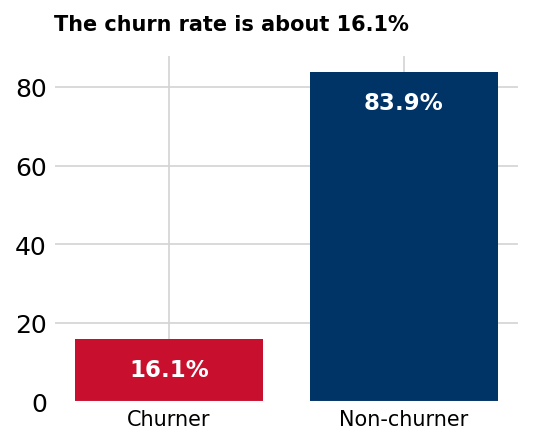

In [21]:
# Define the plot.
fig, ax = plt.subplots(figsize=(4, 3))
        
# Plot the barplot. (Using corporate colors: Red for Churner, Navy for Non-churner)
bars = ax.bar(x=churn_grp['churn_flag'], 
              height=churn_grp['pct'], 
              color=['#C8102E', '#003366'])
        
# Customize the plot.
ax.set_title('The churn rate is about 16.1%', fontweight='bold', fontsize=10, pad=12, loc='left')
ax.set_xlabel('')
ax.set_xticks(ticks=[0, 1], labels=['Non-churner', 'Churner'], fontsize=10)
ax.tick_params(axis='both', which='both', length=0)
ax.invert_xaxis()

# Add percentage annotations inside the bars.
for bar in bars:
    height = bar.get_height()
    ax.annotate('{:.1f}%'.format(height), 
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, -15),  # To fit the text inside the bar
                textcoords="offset points",
                ha='center', va='center',
                fontsize=11, color='white', fontweight='bold')

plt.show()

1- I will use stratified hold-out and k-fold cross-validation to keep the churn ratio strictly consistent across all splits, including during hyperparameter tuning.

2- To prevent the model from ignoring the minority class, I will assign higher weights to churners. This heavily penalizes the model for missing a potential churner.

3-Instead of a rigid yes/no prediction, the main goal is to output churn probabilities. By analyzing the precision-recall trade-off, we can provide actionable risk scores rather than binary labels, allowing the business to make smarter decisions.

In [22]:
numplots_features = ['customer_age', 'months_on_book', 'credit_limit', 'total_revolving_bal', 'avg_open_to_buy', 'total_amt_chng_q4_q1', 'total_trans_amt', 'total_trans_ct', 
 'total_ct_chng_q4_q1','avg_utilization_ratio', 'total_relationship_count']

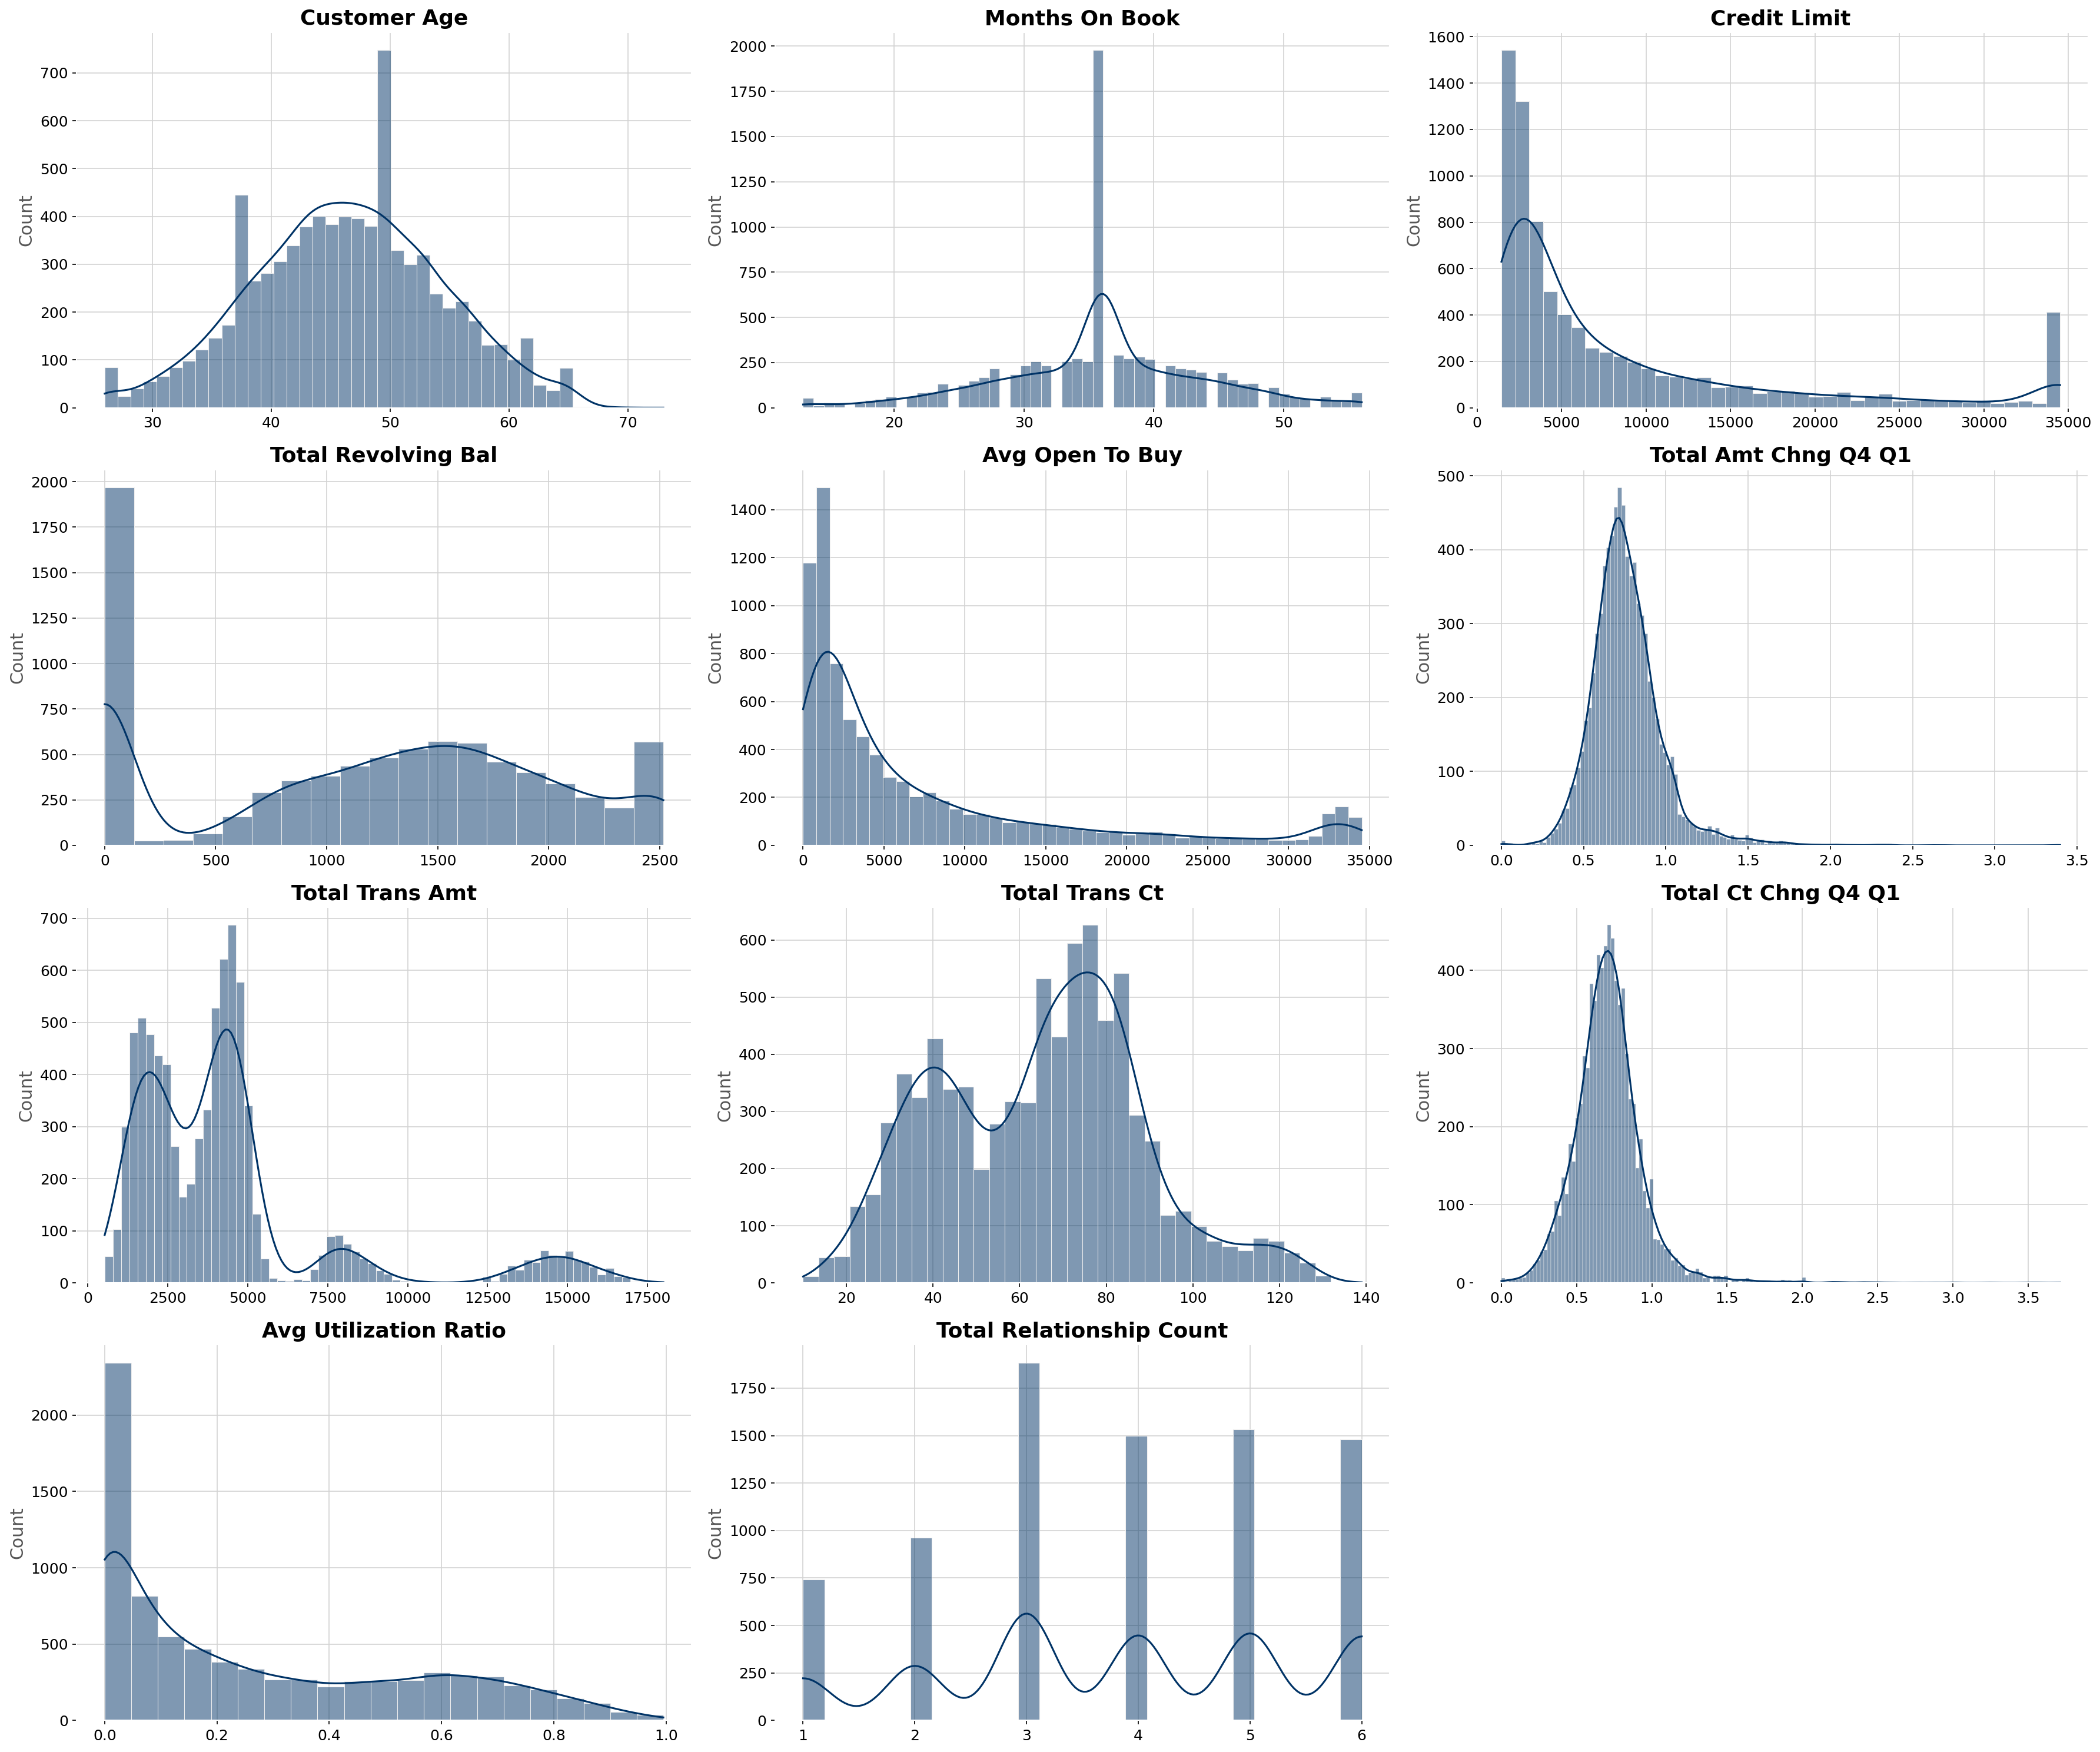

In [23]:

analysis_plots(data=train, features=numplots_features, kde=True, figsize=(24, 20))

Insights:

1- Most customers are in their 40s.

2- Customer tenure heavily spikes at exactly 36 months.

3- Credit limits generally skew low, but a small segment (~5%) holds limits around $35,000.

4- Roughly 25% of users never touch their credit limit. The bank needs new strategies to activate these dormant accounts.

5- Similarly, 25% carry zero revolving balance. This ties into the zero-utilization issue and acts as a massive red flag for churn.

6- Transaction behavior splits into two distinct groups: low-activity (~40 transactions, $2,500) and high-activity (~80 transactions, $5,000). This divide will be key in classifying churners.

7- Over 80% of customers hold at least three different bank products.

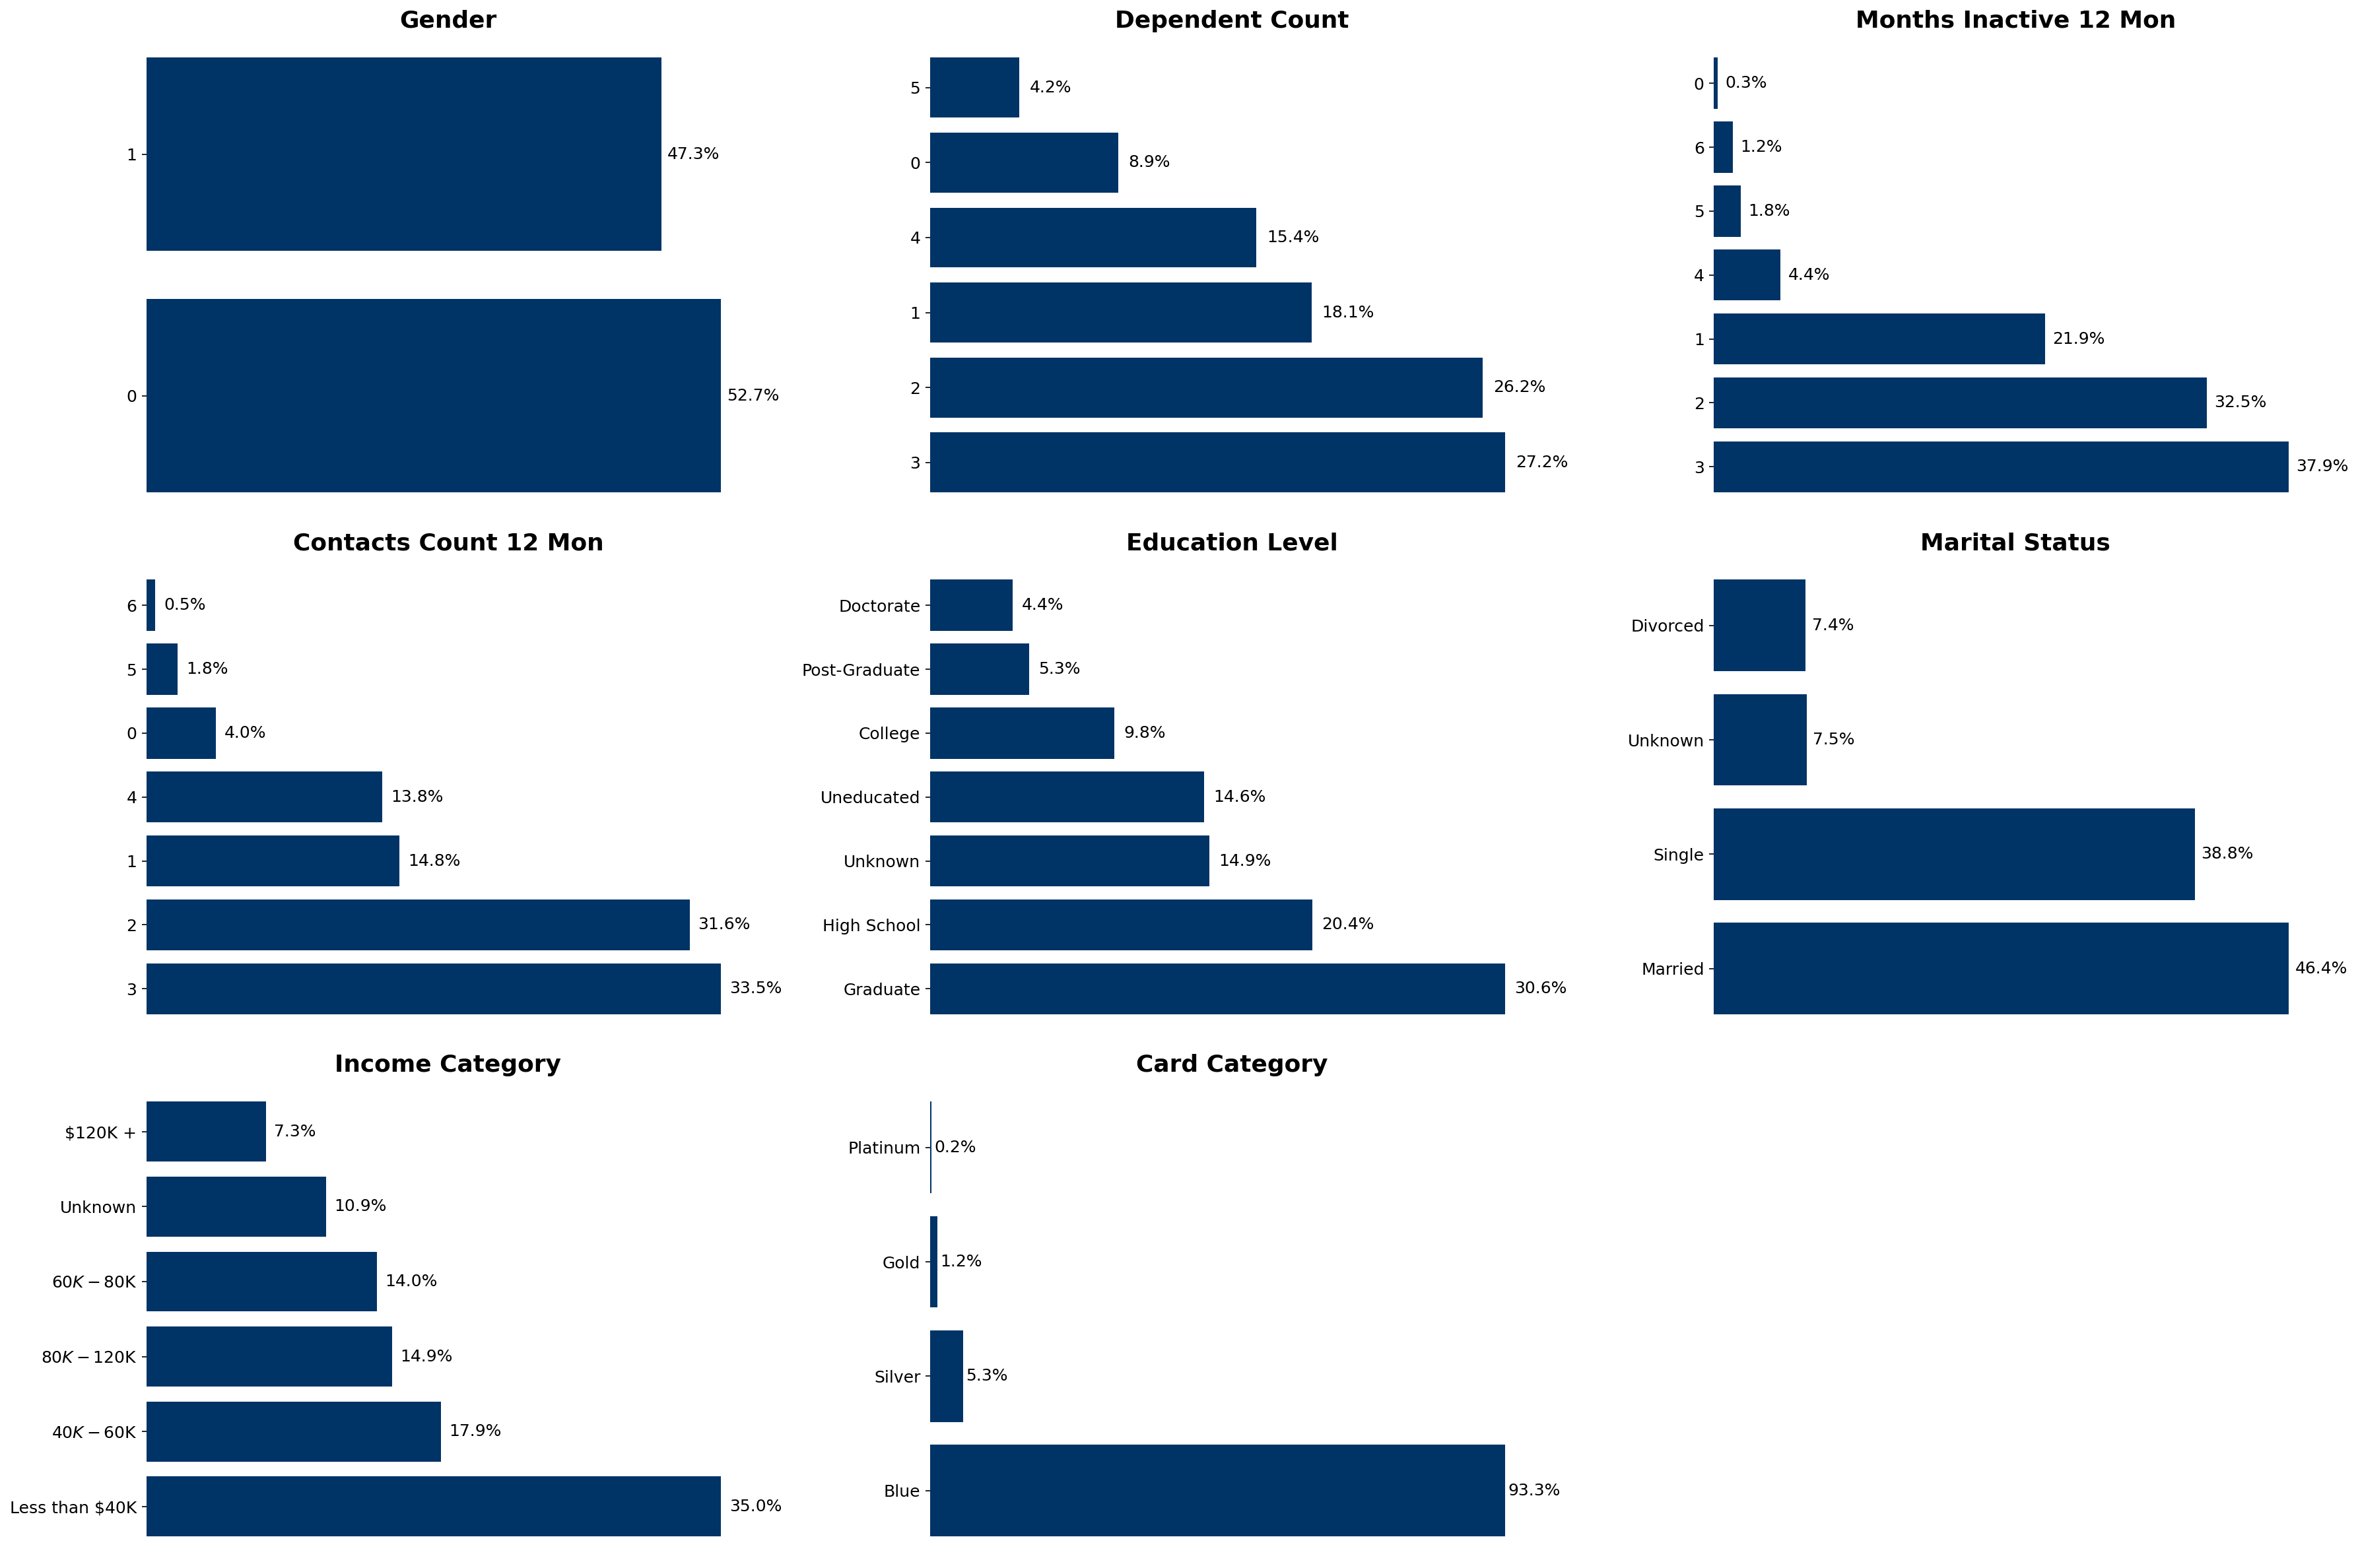

In [24]:
barplot_discrete_features = ['gender', 'dependent_count', 'months_inactive_12_mon', 'contacts_count_12_mon']
barplot_features = barplot_discrete_features + categorical_features

# Kategorik & Ayrık Değişken Dağılımları (Univariate)
analysis_plots(data=train, features=barplot_features, barplot=True, figsize=(24, 16))

**Insights:**
- Almost 53% of the customers are female.
- More than 50% of the customers have 2 or 3 dependents.
- 90% of the customers were inactive from 1 to 3 months in the last year. The bank must plan strategies not only to increase the utilization ratio, but also to avoid customer inactivity.
- Most of the customers (approximately 65% of them) contacted the bank 2 or 3 times in the last 12 months. 
- Most of the customers are married or single, graduate, make less than $40K and hold a blue credit card.
- There are some categories with extremely low proportions of observations, like 0 months inactive and 6 contacts count in the last 12 months. Moreover, card category is highly imbalanced, with almost 99% of the customers having blue or silver types. Particularly, blue corresponds to 93.3% of the observations. This will be taken into account in the modeling step. Leaving categories with extremely low proportions of observations can lead to overfitting and card category may not have discriminatory power.

### Outliers



──────────────────────────────────────────────────
  OUTLIER ANALYSIS (IQR Method)
──────────────────────────────────────────────────
  customer_age                        → 2 (0.02%)
  months_on_book                      → 450 (5.55%)
  credit_limit                        → 784 (9.68%)
  total_revolving_bal                 → None
  avg_open_to_buy                     → 775 (9.57%)
  total_amt_chng_q4_q1                → 311 (3.84%)
  total_trans_amt                     → 704 (8.69%)
  total_trans_ct                      → 1 (0.01%)
  total_ct_chng_q4_q1                 → 317 (3.91%)
  avg_utilization_ratio               → None
  total_relationship_count            → None
──────────────────────────────────────────────────
  Total: 3344 outliers
──────────────────────────────────────────────────


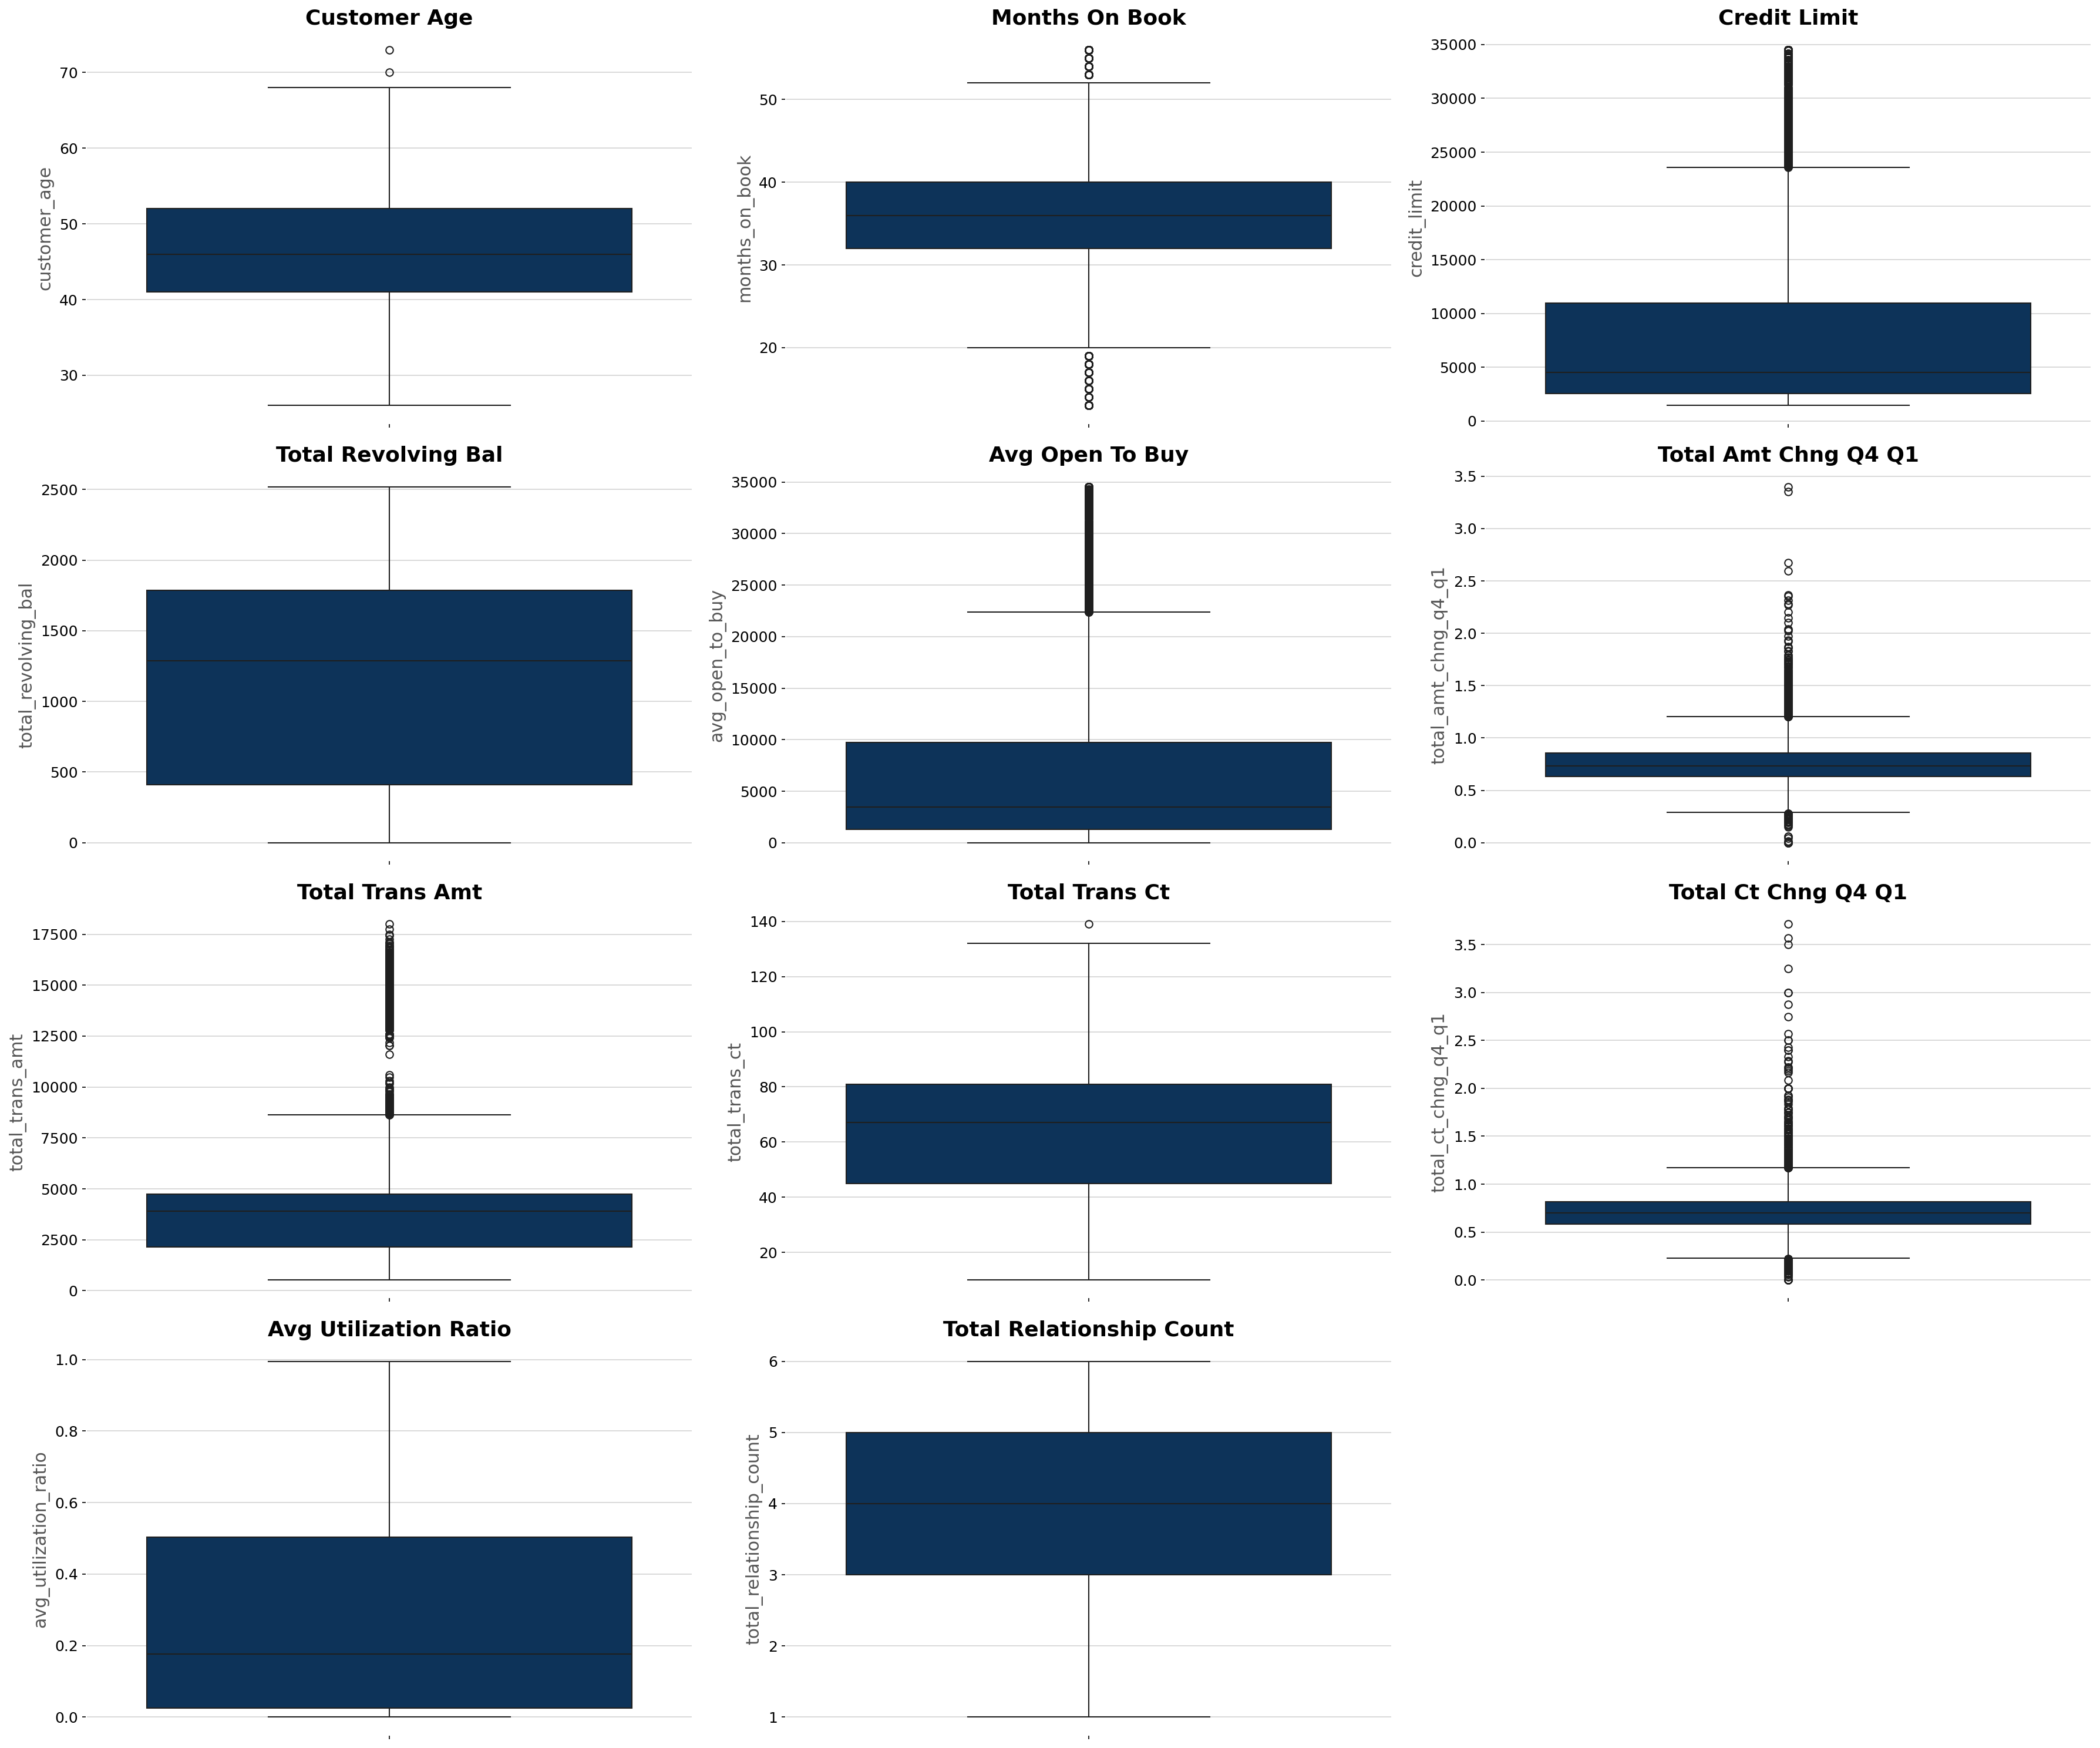

In [25]:
# IQR
outlier_indexes, outlier_counts, total_outliers = check_outliers(data=train, features=numplots_features)


analysis_plots(data=train, features=numplots_features, outliers=True, figsize=(24, 20))

###  Churn vs Non-Churn



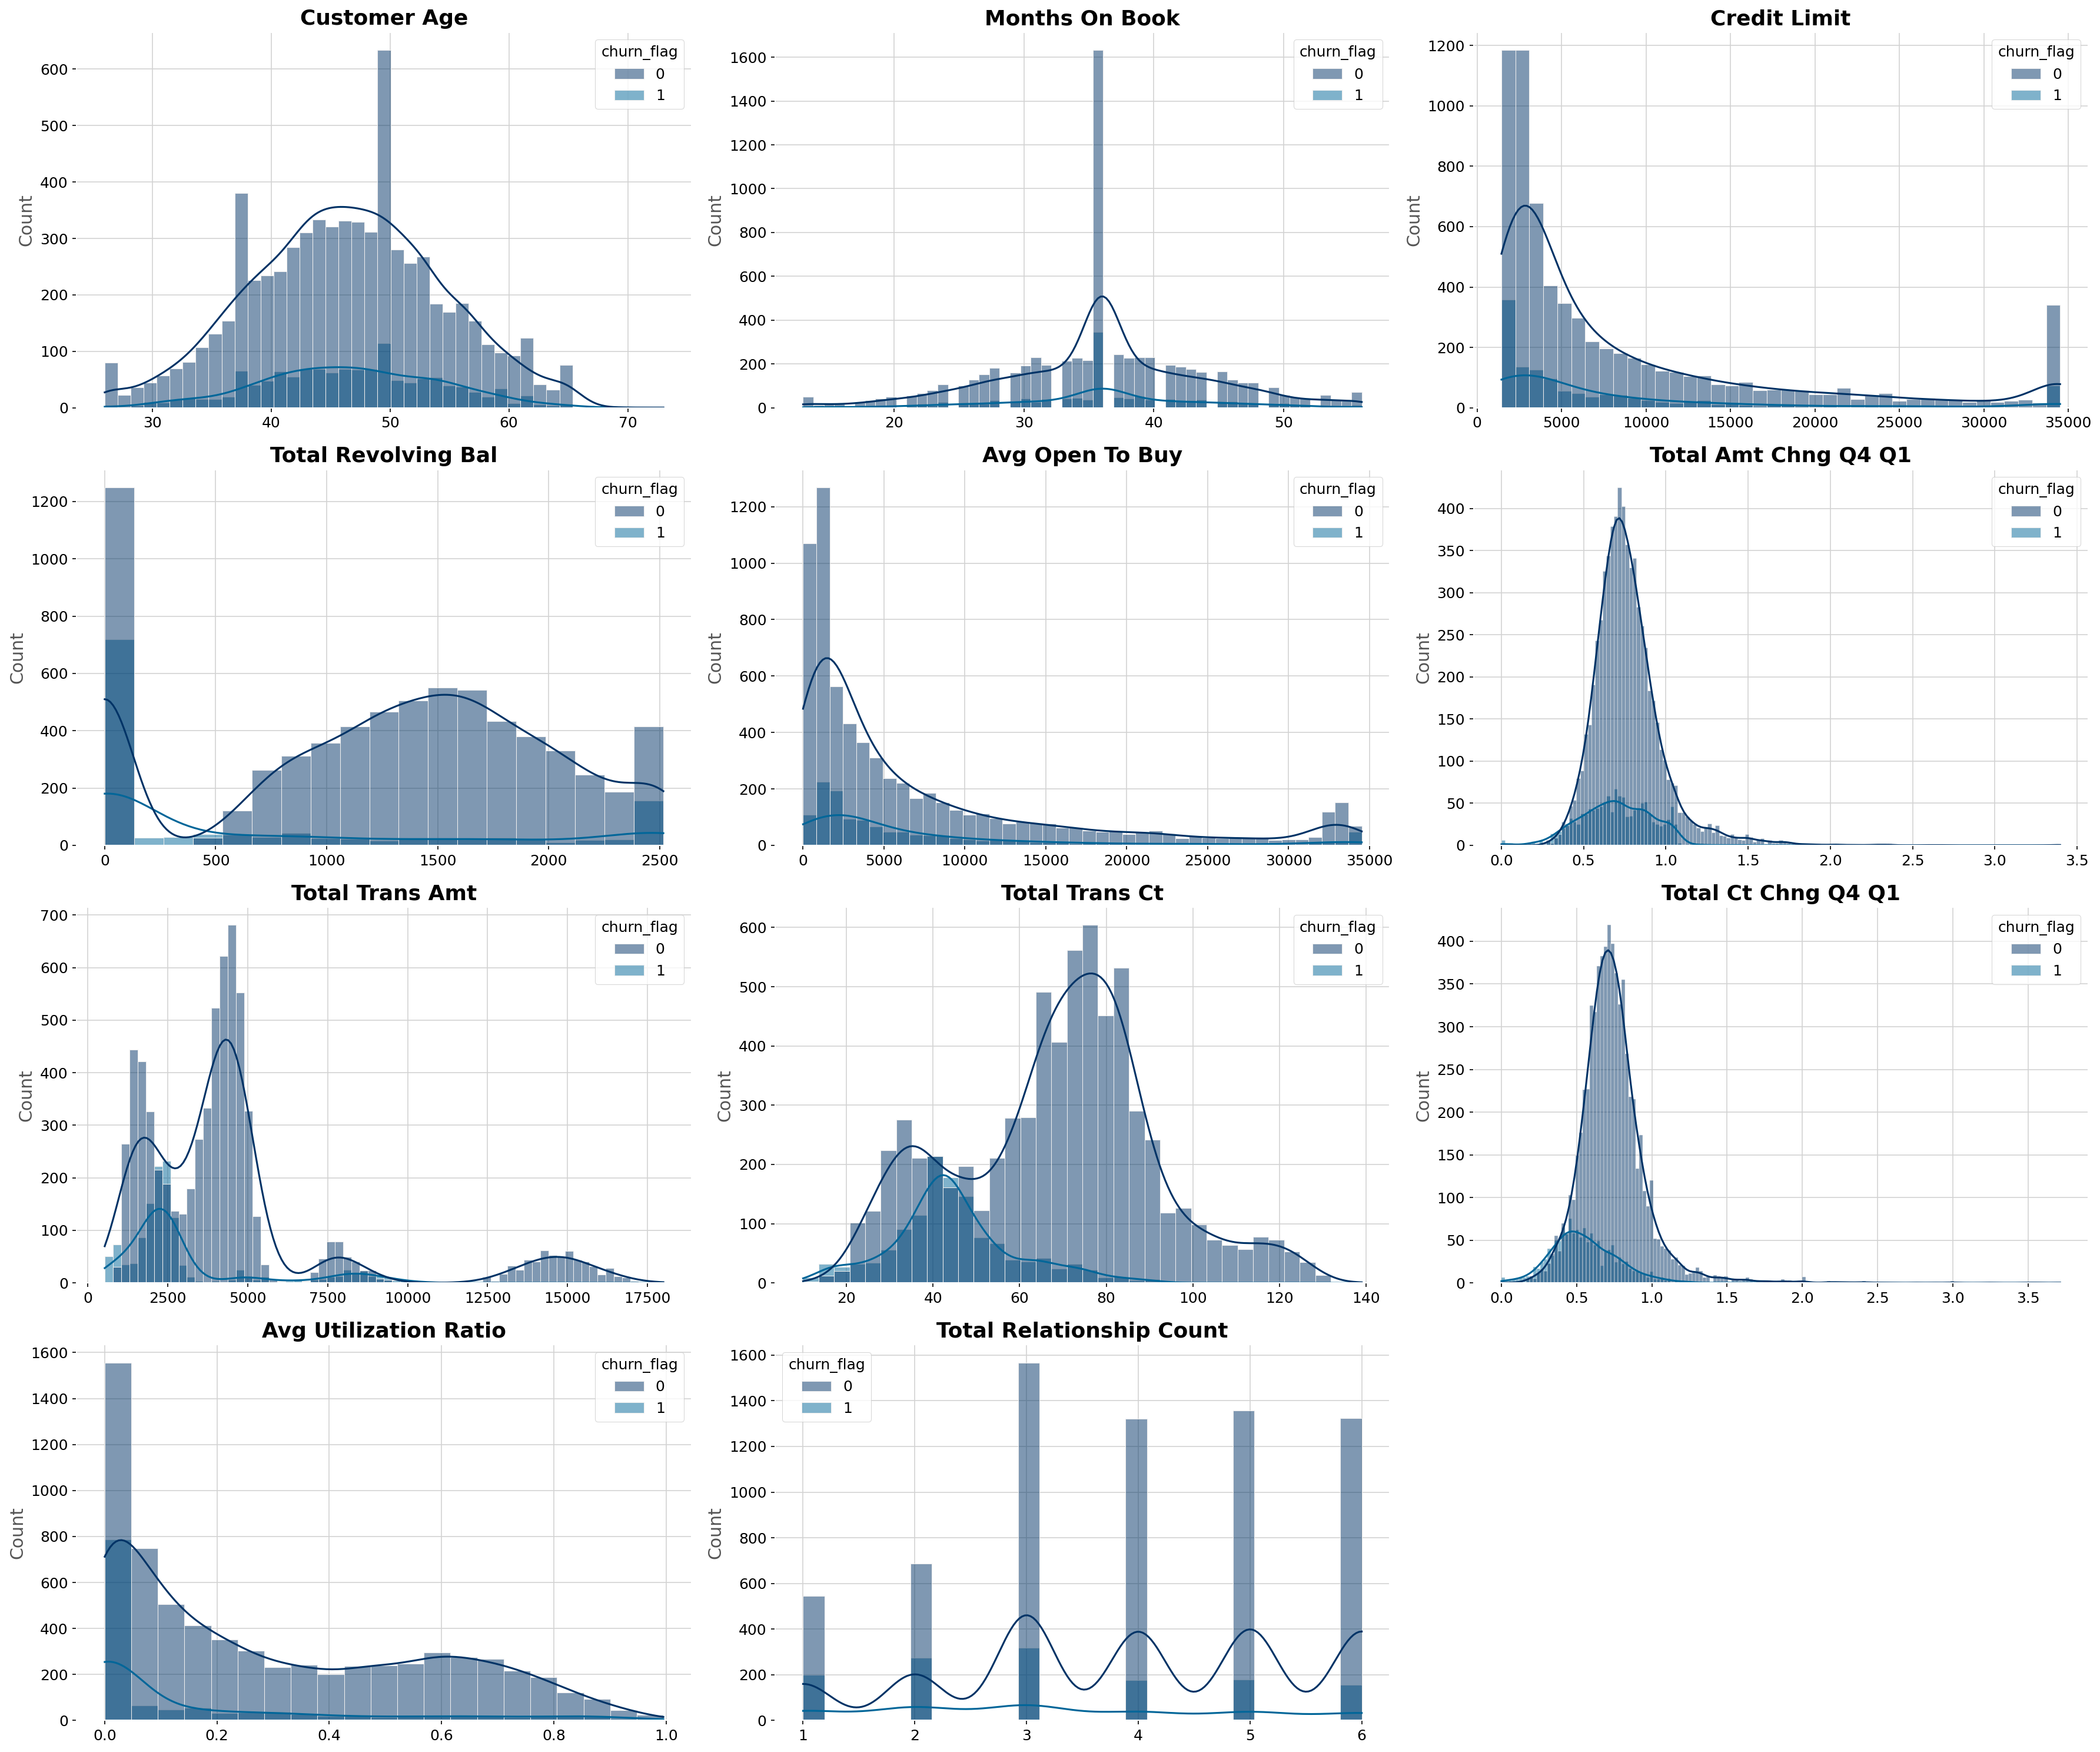

In [26]:

analysis_plots(data=train, features=numplots_features, kde=True, hue='churn_flag', figsize=(24, 20))

In [27]:

target_corr = show_target_correlation(data=train, target='churn_flag', features=numplots_features)

──────────────────────────────────────────────────
  Correlation with 'churn_flag'
──────────────────────────────────────────────────
  customer_age                        ↑ +0.0173
  months_on_book                      ↑ +0.0081
  avg_open_to_buy                     ↑ +0.0002
  credit_limit                        ↓ -0.0240
  total_amt_chng_q4_q1                ↓ -0.1292
  total_relationship_count            ↓ -0.1571
  total_trans_amt                     ↓ -0.1735
  avg_utilization_ratio               ↓ -0.1885
  total_revolving_bal                 ↓ -0.2676
  total_ct_chng_q4_q1                 ↓ -0.2865
  total_trans_ct                      ↓ -0.3725
──────────────────────────────────────────────────


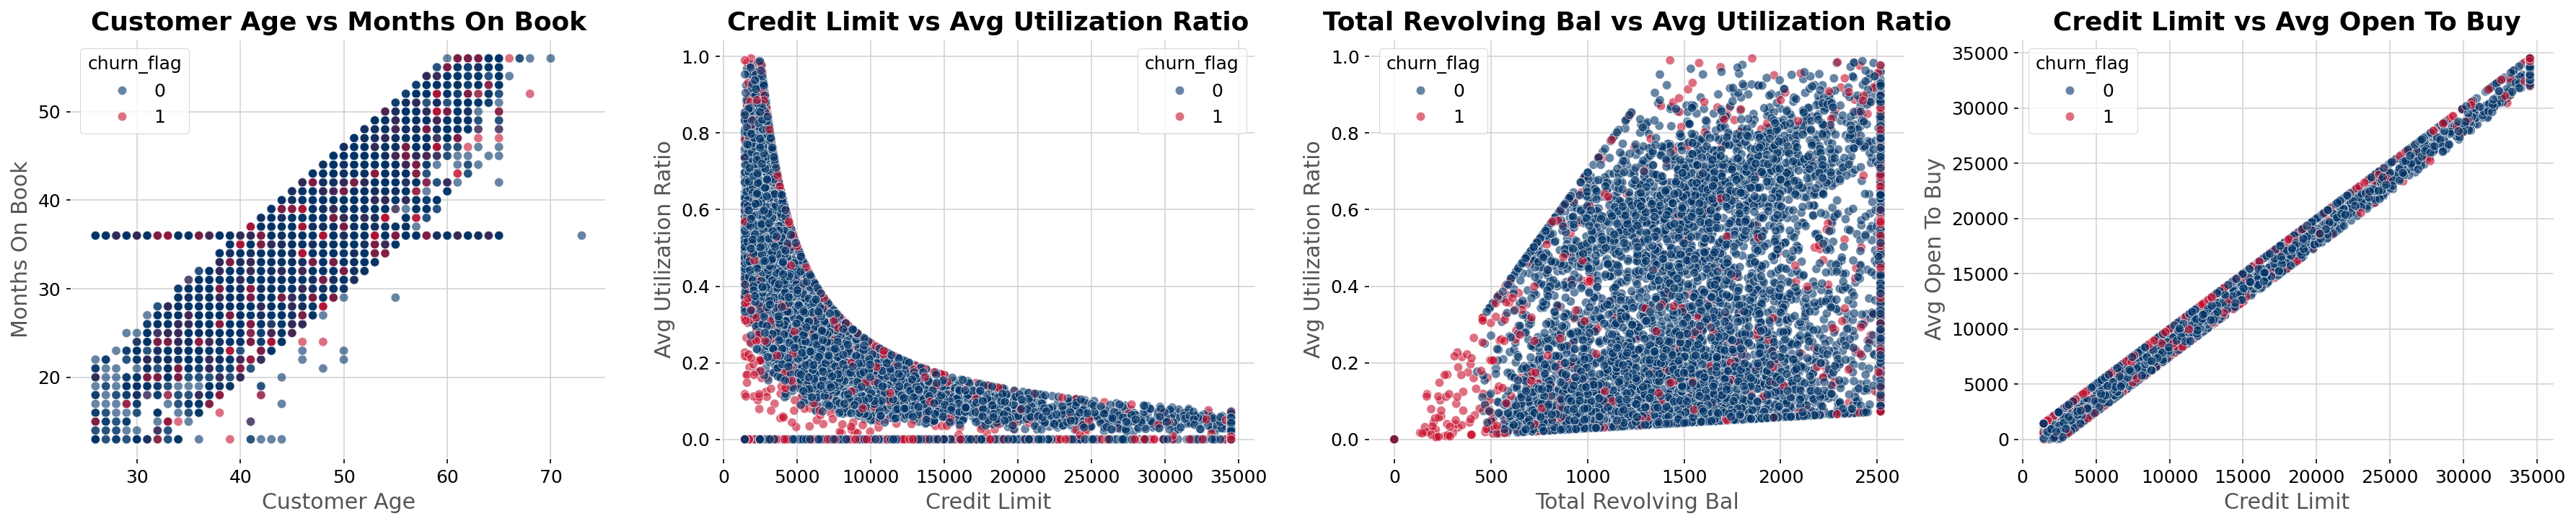

In [28]:

scatter_plots(
    data=train,
    pairs=[
        ('customer_age', 'months_on_book'),
        ('credit_limit', 'avg_utilization_ratio'),
        ('total_revolving_bal', 'avg_utilization_ratio'),
        ('credit_limit', 'avg_open_to_buy')
    ],
    hue='churn_flag',
    figsize=(24, 5)
)

Insights:

Customer age and months on book show a strong positive linear relationship, confirming older customers naturally have longer tenures.

Credit limit and average utilization ratio are negatively correlated. Notably, attrited customers are heavily concentrated at the lowest utilization levels, regardless of their assigned limits.

Total revolving balance and average utilization ratio are strongly positively correlated. A large, dense cluster of churned customers sits exactly at zero balance and zero utilization, reinforcing that total financial inactivity strongly precedes churn.

Average open to buy and credit limit are perfectly correlated, forming a flawless diagonal line. Because they carry identical mathematical information, avg_open_to_buy must be dropped to prevent redundancy in the model

### Bivariate Analysis: Numerical Features vs Churn



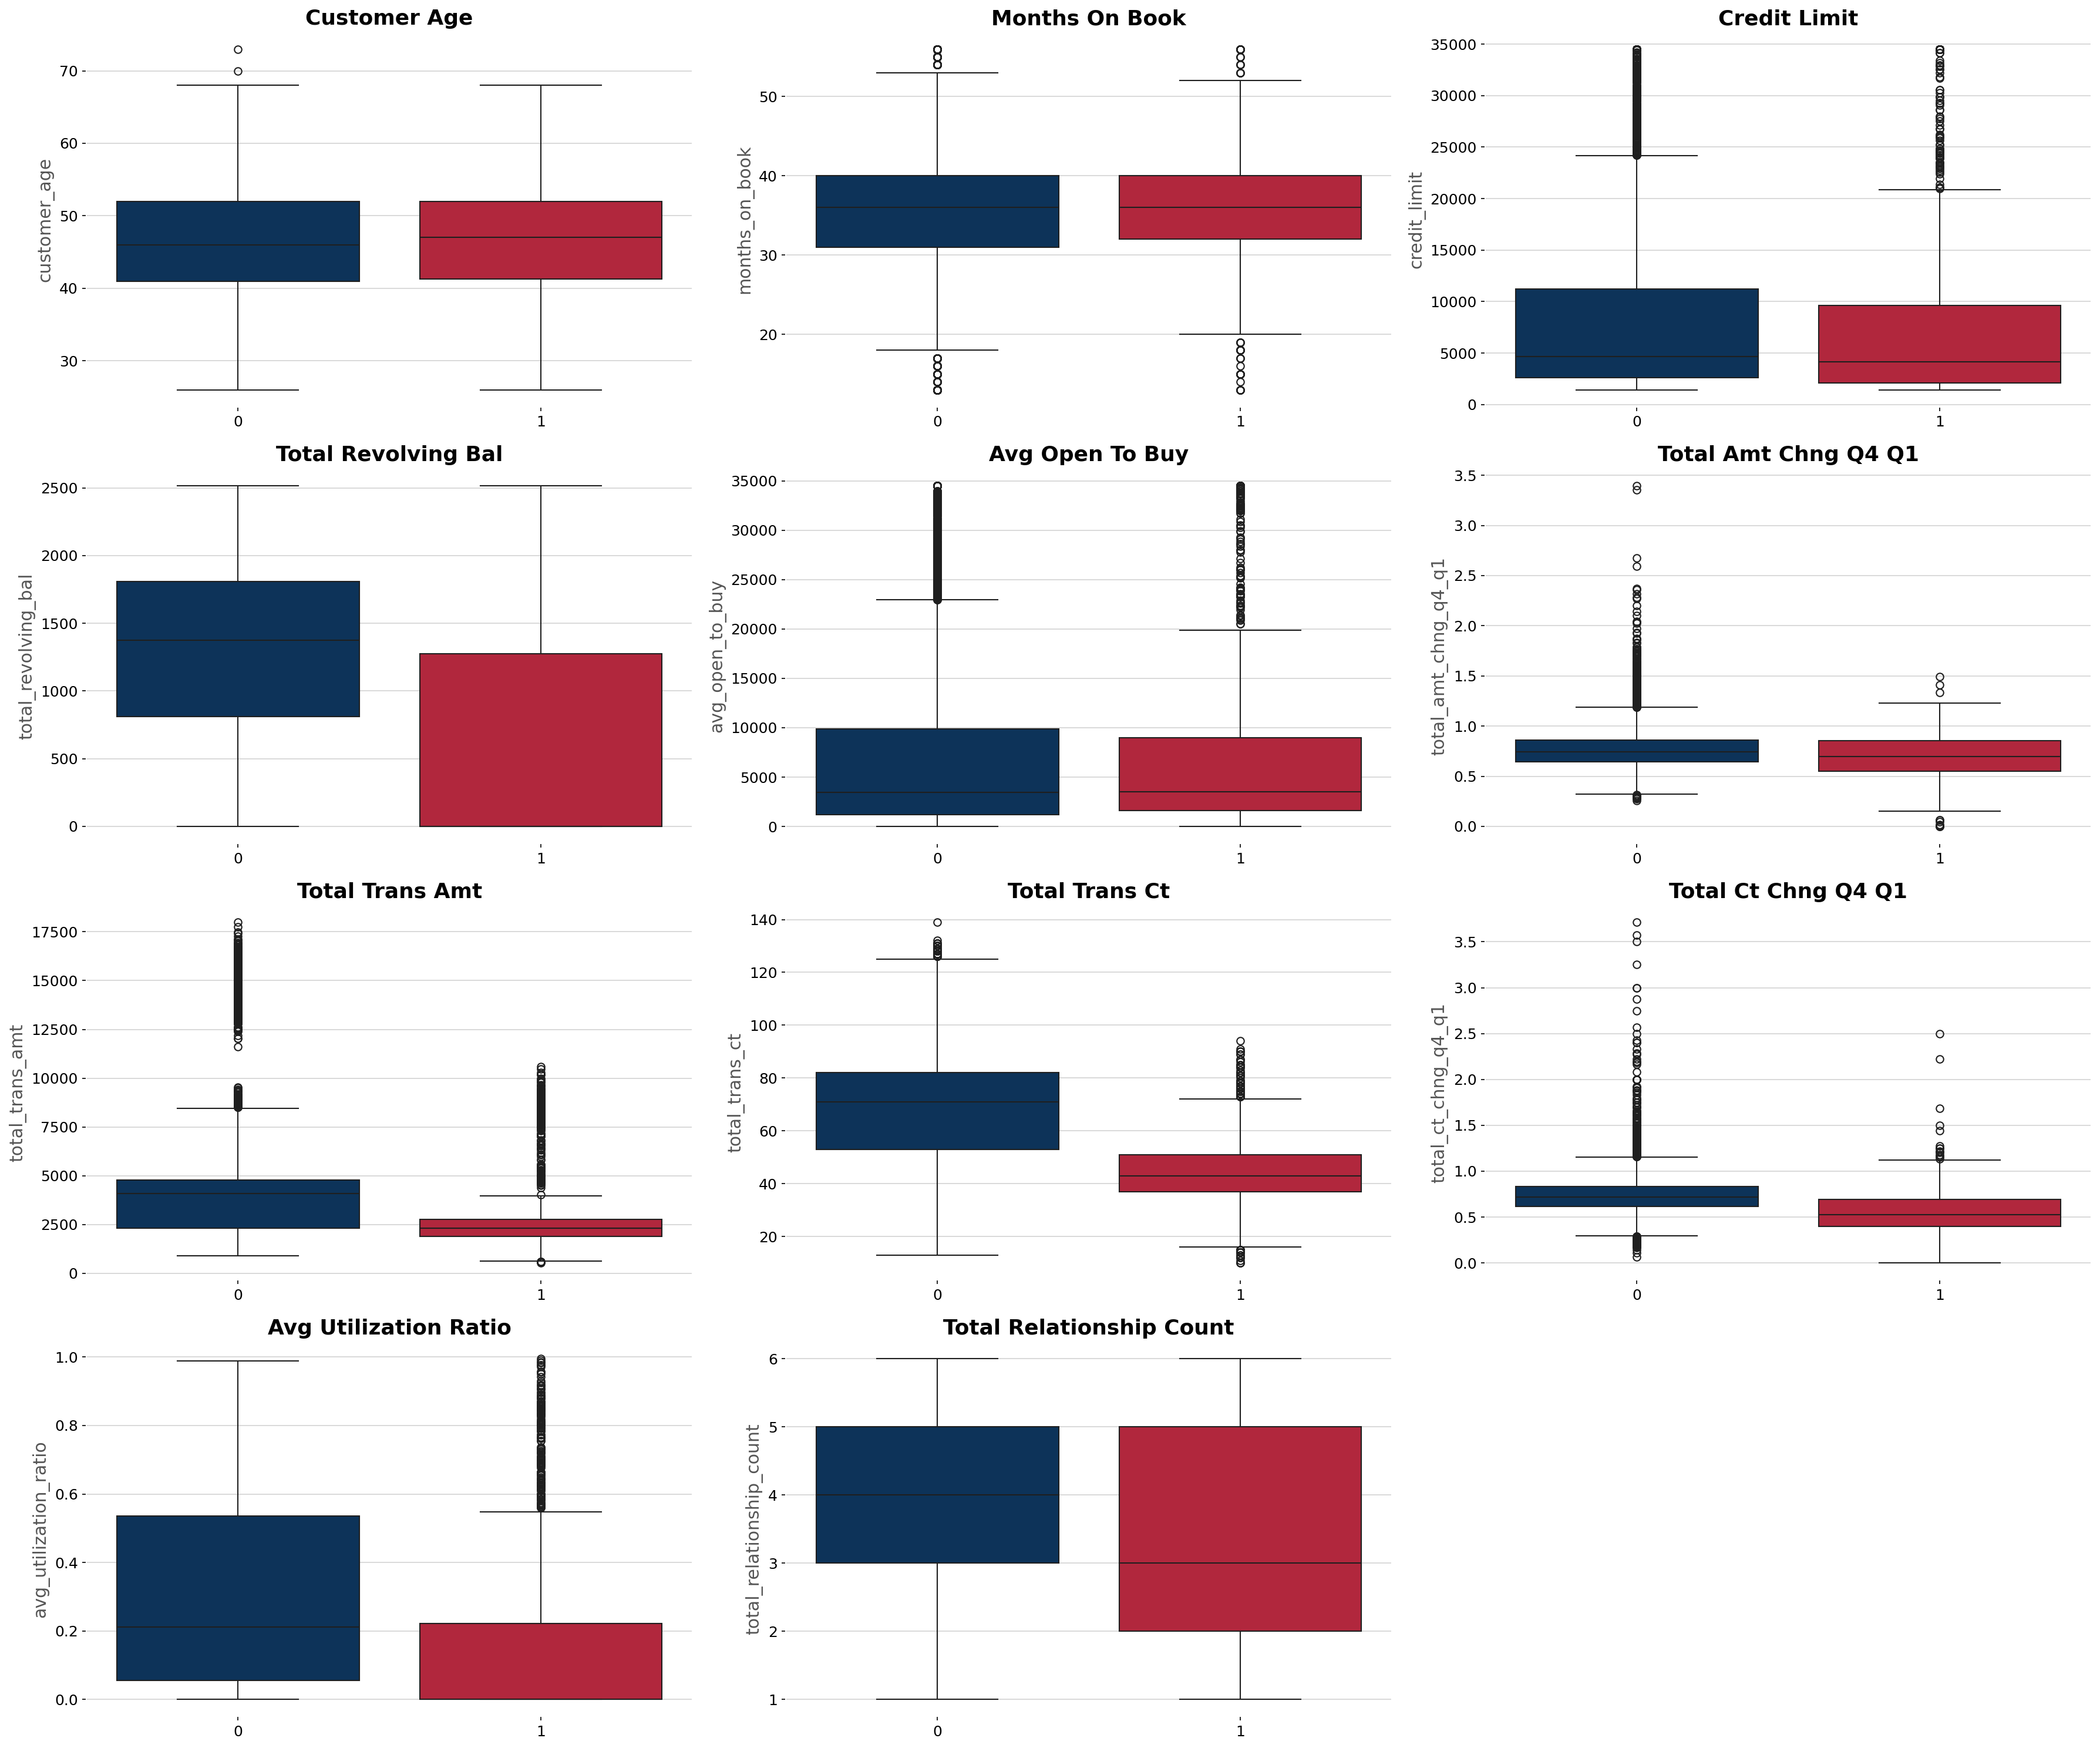

In [29]:
# Sayısal Features vs Churn (Bivariate Boxplot)
analysis_plots(data=train, features=numplots_features, boxplot=True, boxplot_x='churn_flag', figsize=(24, 20))

Insights:
Churned customers generally hold fewer bank products, typically between 1 and 3.

They tend to have slightly lower credit limits.

Revolving balances are significantly lower for churners, often dropping to zero due to decreased card usage.

Both transaction amounts and transaction counts are noticeably lower for customers preparing to leave.

Variation in transaction counts is also lower for churners because of their reduced overall activity.

The average utilization ratio is lower for churners, with many having a ratio of exactly zero.

Continuous features will not be discretized during preprocessing to avoid harmful dimensionality increases, as robust models like LightGBM can already discriminate them effectively.

### Bivariate Analysis: Categorical Features vs Churn



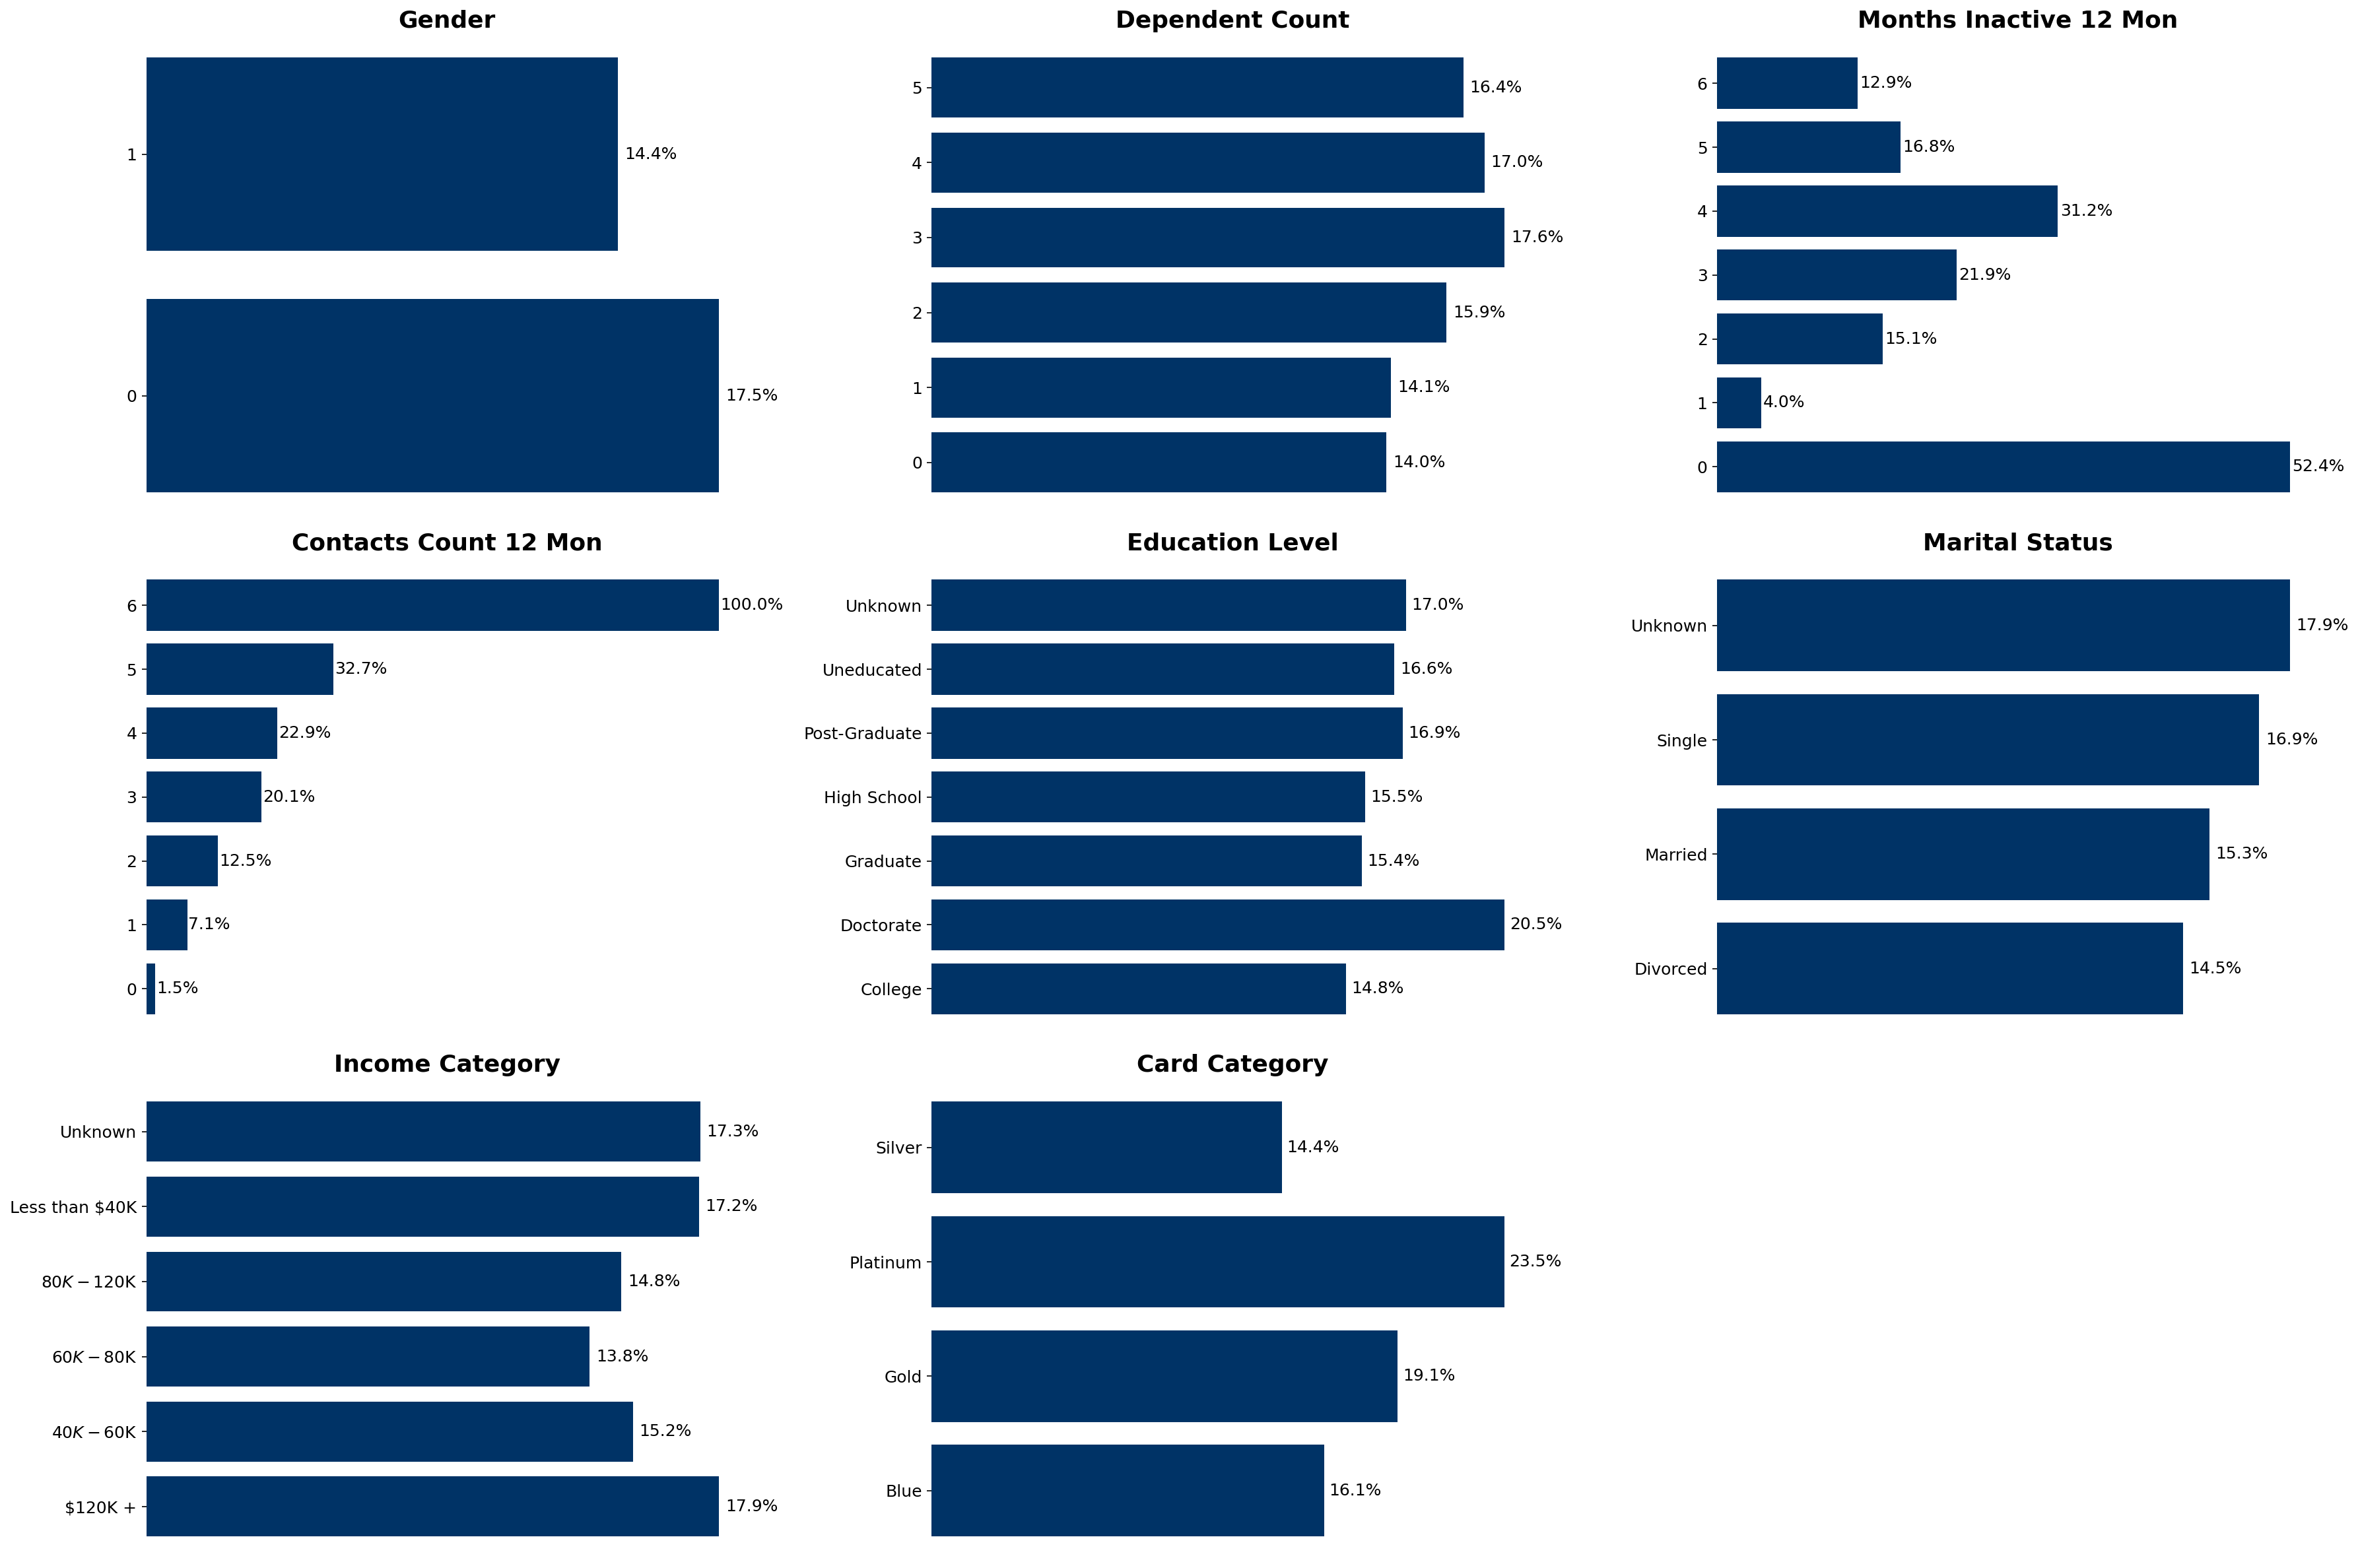

In [30]:
# Kategorik Features vs Churn Rate (Bivariate Barplot)
barplot_discrete_features = ['gender', 'dependent_count', 'months_inactive_12_mon', 'contacts_count_12_mon']
barplot_features = barplot_discrete_features + categorical_features

analysis_plots(data=train, features=barplot_features, barplot=True, hue='churn_flag', text_y=0.2, figsize=(24, 16))

**Insights:**
- The churn rate consistently increases monotonically as the number of contacts with the bank rises. Especially, all customers who made six contacts churned.
- In marital_status, the unknown category presents the highest churn rate. For education_level and income_category, it presents the second highest churn rates. Thus, it is a good practice to leave it as another category of these variables in the preprocessing step, once it helps discriminating between churners and non-churners.
- Although card_category is highly imbalanced towards blue type, it is possible to see that the churn rate varies across the categories. Particularly, Platinum presents the highest churn rate. Even having a very low number of observations, as I am focusing on the predictive power, building robust models such as LightGBM, I will leave this variable and assess its feature importance or apply a feature selection method to keep it or remove it further.
- The churn rate is higher for women.
- Surprisingly, customers who were never inactive in the last 12 months present the highest churn rate.
- Customers with doctorate educational level present the highest churn rate among the other levels.

### Correlation Analysis

check the linear correlations between numerical features to spot potential multicollinearity.

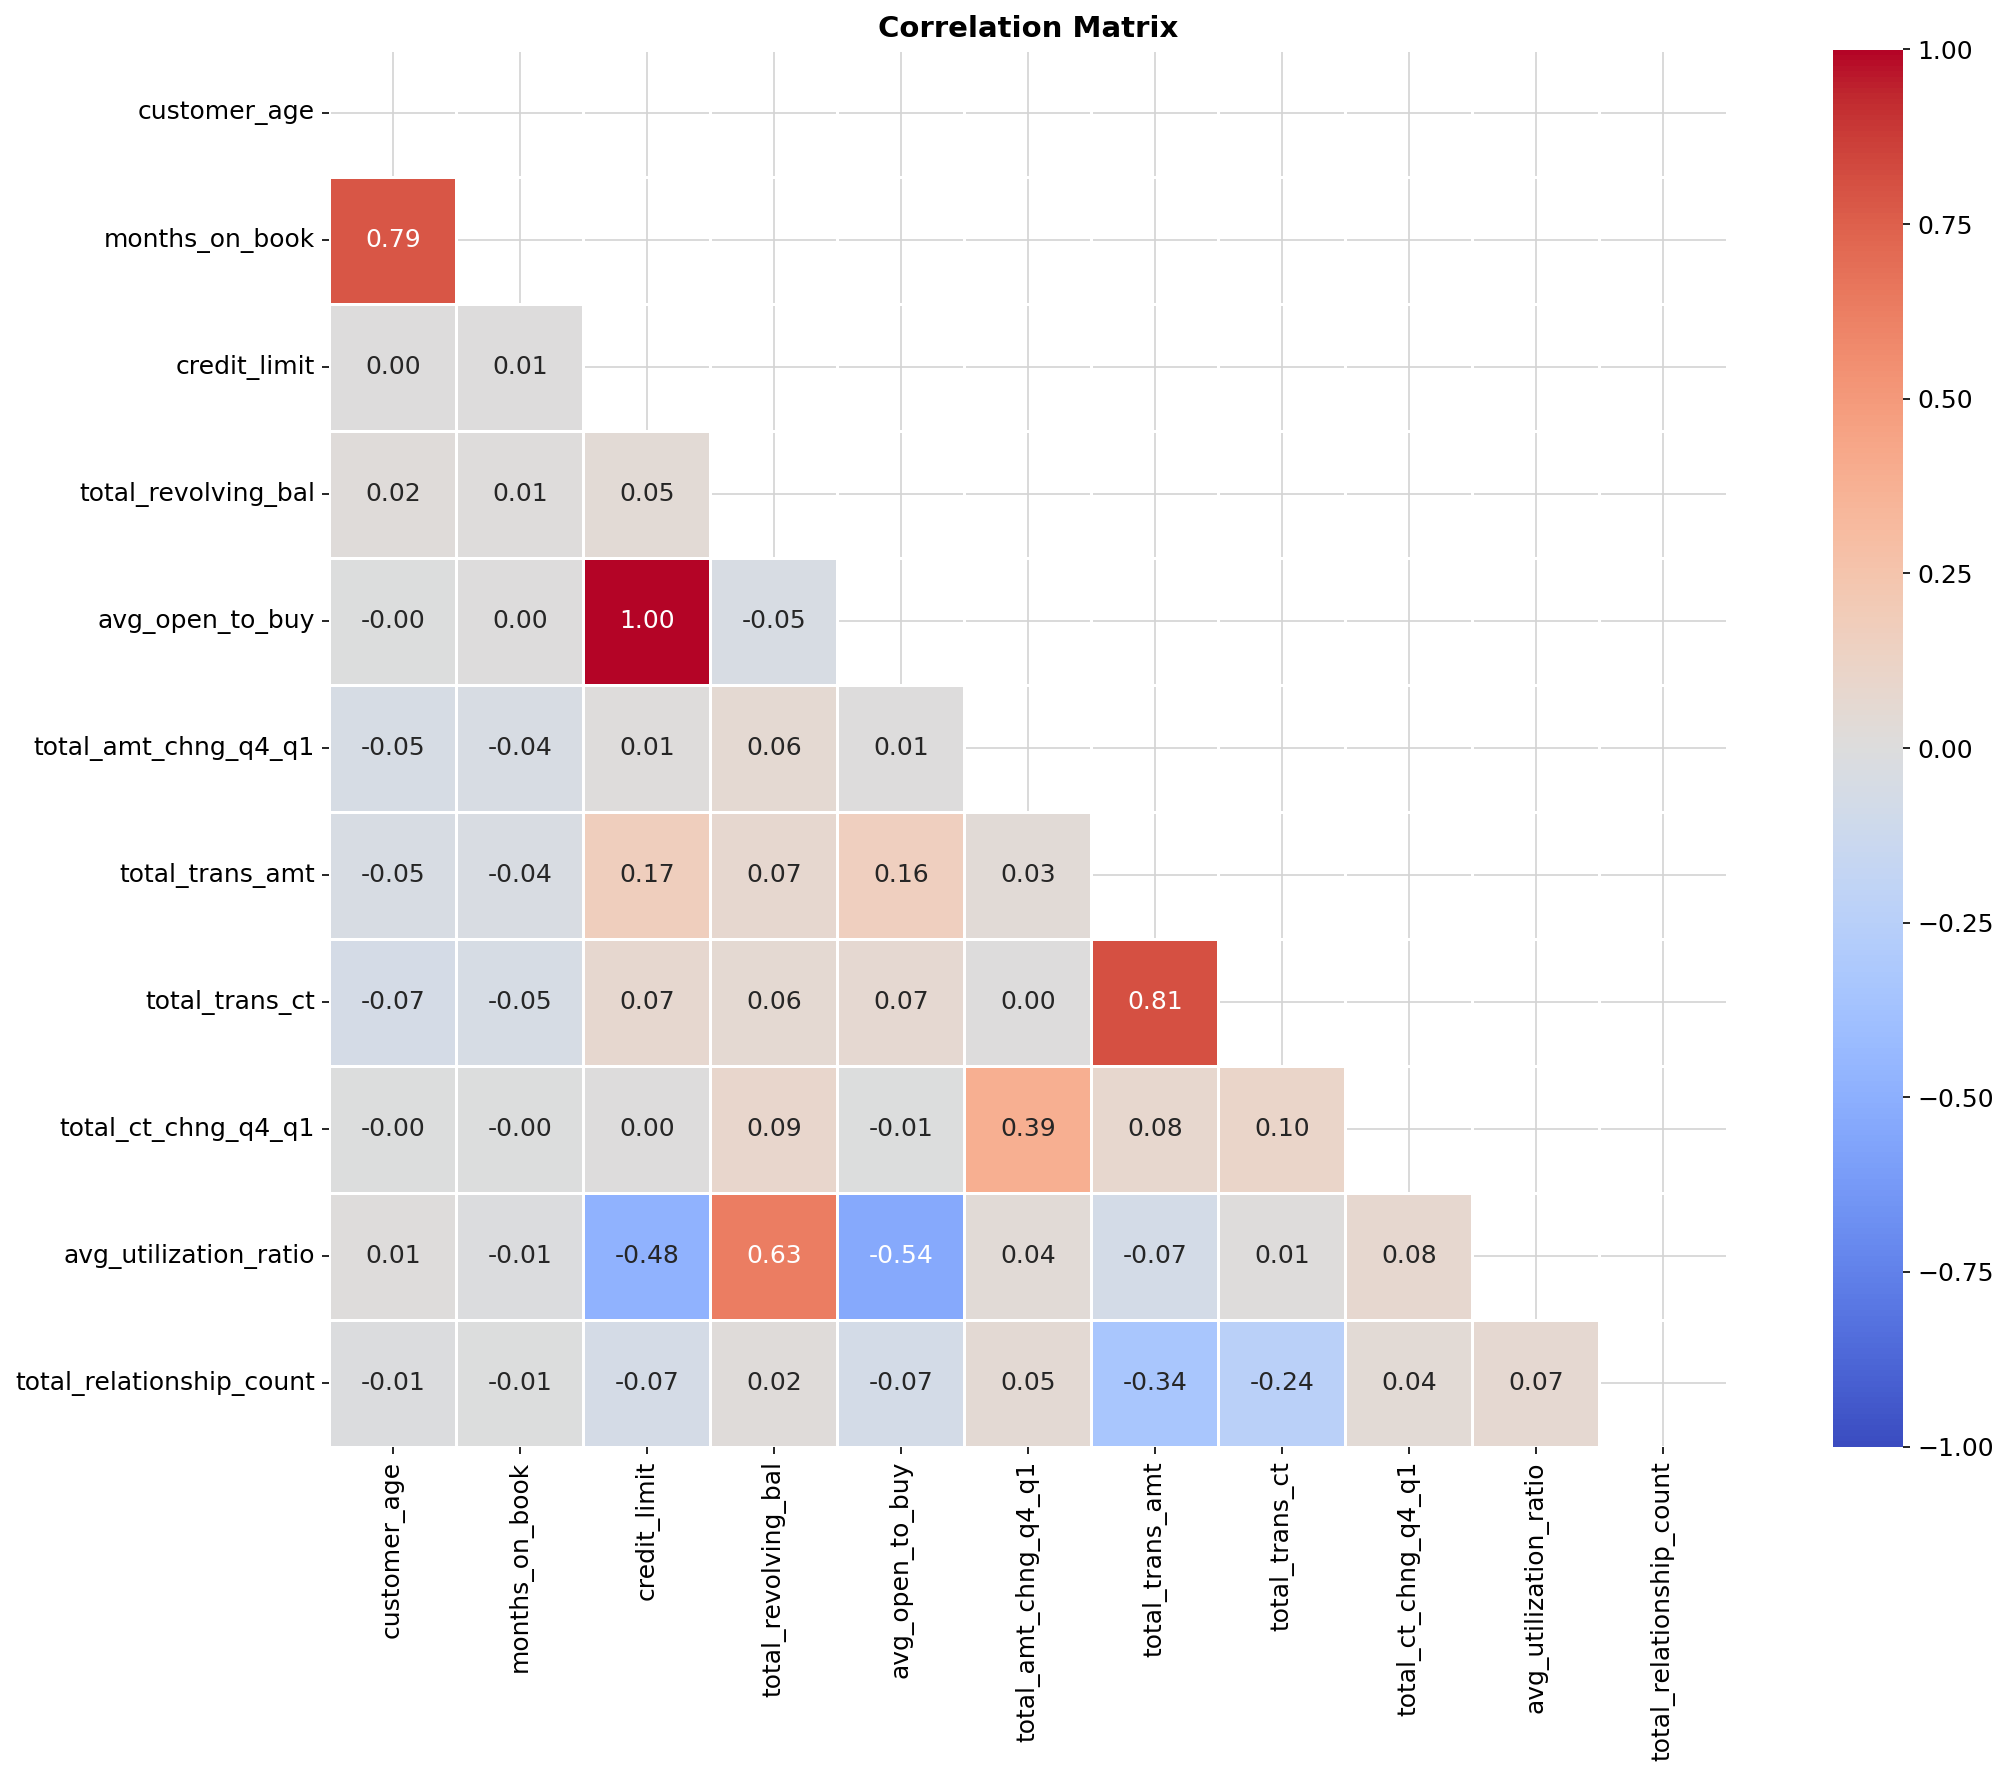

In [31]:
# Korelasyon Matrisi
plot_correlation_matrix(data=train, features=numplots_features, figsize=(16, 12))

Lower transaction counts, less variation in transactions, and lower revolving balances strongly indicate potential churn due to inactivity.

Customer age and months on book are strongly positively correlated.

Higher credit limits lead to lower utilization ratios, while higher utilization naturally increases revolving balances.

Male customers tend to receive higher credit limits than female customers.

Total transaction amount and count are highly correlated, but this multicollinearity is not an issue for robust algorithms like LightGBM.

Average open to buy and credit limit are perfectly correlated, so avg_open_to_buy will be dropped to avoid redundancy.